In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

import numpy as np
from matplotlib.gridspec import GridSpec

FONT = '/System/Library/Fonts/Hiragino Sans GB.ttc'
font_manager.fontManager.addfont(FONT)
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 中文 OK')

✅ 中文 OK


In [11]:
df = pd.read_csv('../data/招商银行.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()
df['MA5']  = df['收盘'].rolling(5).mean()
df['MA20'] = df['收盘'].rolling(20).mean()
df['MA60'] = df['收盘'].rolling(60).mean()
df['收益率'] = df['收盘'].pct_change() * 100
print('行数:', len(df), '| 区间:', df.index[0].date(), '→', df.index[-1].date())
df[['收盘','MA5','MA20','收益率']].tail(3)

行数: 250 | 区间: 2025-07-01 → 2026-07-10


,收盘,MA5,MA20,收益率
日期,,,,
2026-07-08,36.94,36.33,36.4250,1.067031
2026-07-09,36.55,36.52,36.3575,-1.055766
2026-07-10,36.88,36.73,36.3150,0.902873


In [13]:
d= df.iloc[-120:]

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(3, 2, figure=fig,
        height_ratios=[3, 1, 1.2],
        hspace=0.35, wspace=0.22)

<Figure size 1400x900 with 0 Axes>

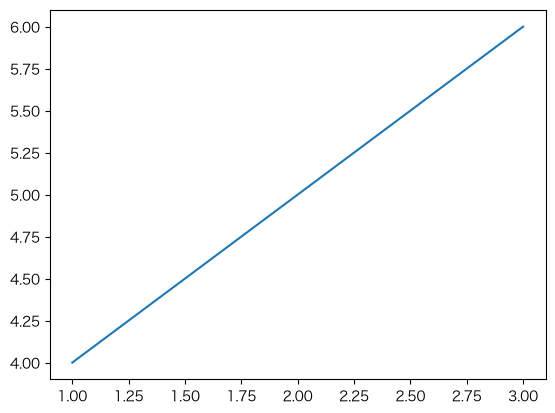

In [16]:
plt.plot([1,2,3], [4,5,6])
plt.show()

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


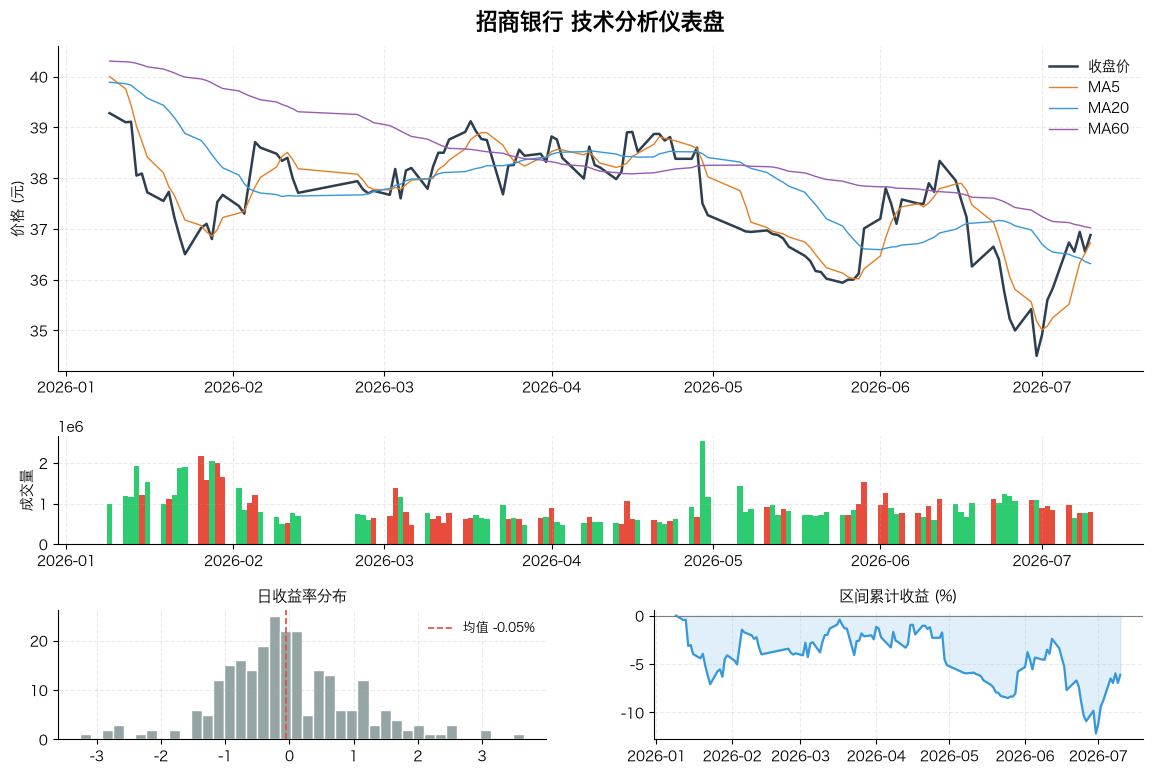

✅ 保存完成


In [19]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec

# 字体
font_manager.fontManager.addfont('/System/Library/Fonts/Hiragino Sans GB.ttc')
plt.rcParams['font.family'] = 'Hiragino Sans GB'
plt.rcParams['axes.unicode_minus'] = False

# 数据
df = pd.read_csv('../data/招商银行.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()
df['MA5']=df['收盘'].rolling(5).mean()
df['MA20']=df['收盘'].rolling(20).mean()
df['MA60']=df['收盘'].rolling(60).mean()
df['收益率']=df['收盘'].pct_change()*100
d = df.iloc[-120:]

# 布局
fig = plt.figure(figsize=(14,9))
gs = GridSpec(3,2,figure=fig,height_ratios=[3,1,1.2],hspace=0.35,wspace=0.22)

# 主图
C_PRICE,C_MA5,C_MA20,C_MA60 = '#2c3e50','#e67e22','#3498db','#9b59b6'
ax1=fig.add_subplot(gs[0,:])
ax1.plot(d.index,d['收盘'],color=C_PRICE,lw=1.8,label='收盘价')
ax1.plot(d.index,d['MA5'],color=C_MA5,lw=1,label='MA5')
ax1.plot(d.index,d['MA20'],color=C_MA20,lw=1,label='MA20')
ax1.plot(d.index,d['MA60'],color=C_MA60,lw=1,label='MA60')
ax1.set_title('招商银行 技术分析仪表盘',fontsize=16,fontweight='bold',pad=12)
ax1.legend(frameon=False); ax1.set_ylabel('价格 (元)')

# ② 成交量（红涨绿跌）
import numpy as np
C_UP, C_DOWN = '#e74c3c', '#2ecc71'
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
vol_colors = np.where(d['收盘'] >= d['开盘'], C_UP, C_DOWN)
ax2.bar(d.index, d['成交量'], color=vol_colors, width=1.0)
ax2.set_ylabel('成交量')

# ③ 收益率直方图
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(df['收益率'].dropna(), bins=40, color='#95a5a6', edgecolor='white')
ax3.axvline(df['收益率'].mean(), color=C_UP, ls='--', lw=1.2,
            label=f"均值 {df['收益率'].mean():.2f}%")
ax3.set_title('日收益率分布', fontsize=11); ax3.legend(frameon=False, fontsize=9)

# ④ 累计收益
ax4 = fig.add_subplot(gs[2, 1])
cum = (1 + d['收盘'].pct_change().fillna(0)).cumprod() - 1
ax4.plot(cum.index, cum * 100, color=C_MA20, lw=1.6)
ax4.fill_between(cum.index, cum * 100, 0, alpha=0.15, color=C_MA20)
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_title('区间累计收益 (%)', fontsize=11)

# 精修 + 出图
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.25, ls='--')

fig.savefig('../day13/招商银行仪表盘.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 保存完成')